# Project 1: Motor Insurance Pricing and Risk Modeling

## Objective

The objective of this project is to analyze a motor insurance portfolio and model claim frequency using actuarial pricing techniques.

The project explores how policyholder, vehicle, and geographic characteristics influence insurance risk.

A Poisson Generalized Linear Model (GLM) is used to estimate expected claim frequency while adjusting for exposure.

This project is designed as a pricing-oriented actuarial analytics case study and will later be extended to include severity and pure premium modeling.

## 1. Imports and Setup

This section loads the Python libraries needed for data manipulation, visualization, and statistical modeling.

The main modeling package used here is `statsmodels`, which supports Generalized Linear Models (GLMs). GLMs are widely used in insurance pricing because they provide interpretable relationships between rating variables and expected claims.

In [109]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling
import statsmodels.api as sm
import statsmodels.formula.api as smf



## 2. Data Loading and Initial Inspection

This section loads the motor insurance dataset and performs an initial inspection.

Before modeling, the first actuarial step is to understand the structure of the portfolio:

- number of policies
- available rating variables
- target variable
- exposure information
- missing values
- data types

The key modeling target is `ClaimNb`, which represents the number of claims observed for each policy.

In [110]:
# Load the motor insurance dataset
df = pd.read_csv("../data/raw/motor-insurance-frequency.csv")

df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'


In [111]:
# Inspect dataset dimensions
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape:
(678013, 12)

Column Names:
Index(['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  object 
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  object 
 9   VehGas      678013 non-null  object 
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB


In [112]:
# Summary statistics for numerical variables
df.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.780130e+05,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000
mean,2.621857e+06,0.053247,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405
std,1.641783e+06,0.240117,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157951e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272152e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046274e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In [113]:
# Distribution of claim counts
df["ClaimNb"].value_counts().sort_index()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

### Initial Observations

The portfolio contains a large number of policies with zero claims, which is common in insurance frequency datasets.

This type of response structure is well suited for count-based models such as the Poisson GLM.

The dataset also includes exposure information, which is critical because policies active for longer durations have greater opportunity to generate claims.

## 3. Data Cleaning and Feature Preparation

Insurance datasets often contain:

- missing values
- invalid exposure periods
- extreme observations
- inconsistent variable ranges

Before modeling, the dataset must be cleaned to ensure stable and interpretable statistical estimates.

This section prepares the portfolio data for claim frequency modeling by:

- removing invalid observations
- handling missing values
- capping extreme values
- creating derived variables for exploratory analysis

In [114]:
# Rename selected columns for readability
df = df.rename(columns={
    "DrivAge": "DriverAge"
})

df.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge',
       'DriverAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'],
      dtype='object')

### Missing Values and Exposure Filtering

Policies with missing modeling variables are removed because GLMs require complete predictor information.

Policies with zero or negative exposure are also removed because exposure represents insured duration.

A policy with zero exposure cannot meaningfully contribute to claim frequency estimation.

In [115]:
# Select variables required for modeling
required_cols = [
    "DriverAge",
    "VehAge",
    "VehPower",
    "Exposure",
    "ClaimNb",
    "BonusMalus",
    "Density",
    "Area",
    "VehGas",
    "Region"
]

# Remove rows with missing required values
df = df.dropna(subset=required_cols).copy()

# Remove invalid exposure values
df = df[df["Exposure"] > 0]

### Capping Extreme Values

Extreme observations can disproportionately influence statistical models.

Driver age and vehicle age are capped to reduce the impact of unrealistic or highly influential observations.

Claim counts are also capped because extremely high claim frequencies are rare and may destabilize Poisson estimation.

In [116]:
# Cap extreme driver and vehicle ages
df["DriverAge"] = df["DriverAge"].clip(lower=18, upper=90)
df["VehAge"] = df["VehAge"].clip(lower=0, upper=30)

# Cap extremely high claim counts
df["ClaimNb_capped"] = df["ClaimNb"].clip(upper=4)

### Claim Frequency

Claim frequency measures the rate of claims relative to exposure.

It is calculated as:

Claim Frequency = Number of Claims / Exposure

This is one of the core quantities used in actuarial pricing because it adjusts claim activity for differing policy durations.

In [117]:
# Calculate observed claim frequency
df["observed_frequency"] = df["ClaimNb"] / df["Exposure"]

df[["ClaimNb", "Exposure", "observed_frequency"]].describe()

,ClaimNb,Exposure,observed_frequency
count,678013.000000,678013.000000,678013.000000
mean,0.053247,0.528750,0.263964
std,0.240117,0.364442,4.593915
min,0.000000,0.002732,0.000000
25%,0.000000,0.180000,0.000000
50%,0.000000,0.490000,0.000000
75%,0.000000,0.990000,0.000000
max,16.000000,2.010000,732.000000


### Age Banding

Age banding is commonly used in insurance analytics to study broad risk patterns across demographic groups.

This improves interpretability during exploratory analysis and risk segmentation.

In [118]:
# Create driver age bands for exploratory analysis
df["age_band"] = pd.cut(
    df["DriverAge"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

df[["DriverAge", "age_band"]].head()

,DriverAge,age_band
0,55,46-55
1,55,46-55
2,52,46-55
3,46,46-55
4,46,46-55


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to investigate relationships between rating variables and observed insurance risk.

The objectives of this section are to:

- study claim frequency patterns
- identify potential risk drivers
- understand portfolio composition
- evaluate whether variables may contribute useful predictive information

The focus is primarily on observed claim frequency across demographic, vehicle, and geographic groupings.

### Claim Frequency by Driver Age

This analysis compares observed claim frequency across driver age groups.

In motor insurance, younger drivers are often associated with higher claim frequency due to:
- lower driving experience
- greater behavioral risk
- higher accident propensity

Older drivers may also exhibit changing risk characteristics at advanced ages.

In [119]:
# Observed claim frequency by driver age band
age_freq = df.groupby("age_band", observed=True).apply(
    lambda x: x["ClaimNb"].sum() / x["Exposure"].sum()
).reset_index(name="observed_frequency")

age_freq

C:\Users\Asus\AppData\Local\Temp\ipykernel_23080\130989072.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_freq = df.groupby("age_band", observed=True).apply(


,age_band,observed_frequency
0,18-25,0.175069
1,26-35,0.096179
2,36-45,0.095744
3,46-55,0.103687
4,56-65,0.091704
5,65+,0.094853


### Visual Interpretation

The visualization helps identify whether claim frequency varies meaningfully across driver age groups.

Strong variation across age bands would support the inclusion of driver age as a rating variable in the GLM.

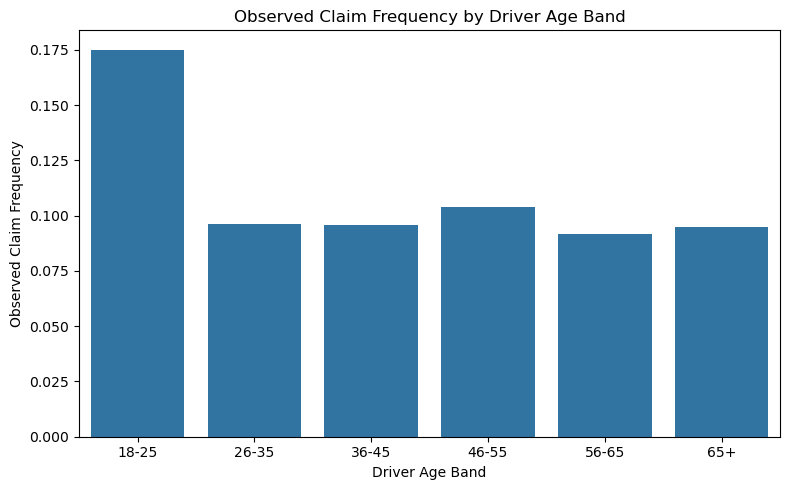

In [120]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_freq,
    x="age_band",
    y="observed_frequency"
)

plt.title("Observed Claim Frequency by Driver Age Band")
plt.xlabel("Driver Age Band")
plt.ylabel("Observed Claim Frequency")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/claim_frequency_by_age_band.png"
)

plt.show()

### Vehicle Power and Insurance Risk

Vehicle power may indirectly capture:
- driving behavior
- speed potential
- vehicle usage patterns
- driver demographics

The relationship is not assumed to be strictly causal.

Instead, exploratory analysis is used to determine whether vehicle power contains predictive information relevant for insurance pricing.

In [121]:
# Observed claim frequency by vehicle power
vehpower_freq = df.groupby("VehPower").apply(
    lambda x: x["ClaimNb"].sum() / x["Exposure"].sum()
).reset_index(name="observed_frequency")

vehpower_freq.head()


C:\Users\Asus\AppData\Local\Temp\ipykernel_23080\2216553973.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vehpower_freq = df.groupby("VehPower").apply(


,VehPower,observed_frequency
0,4,0.094867
1,5,0.106757
2,6,0.101558
3,7,0.097844
4,8,0.084727


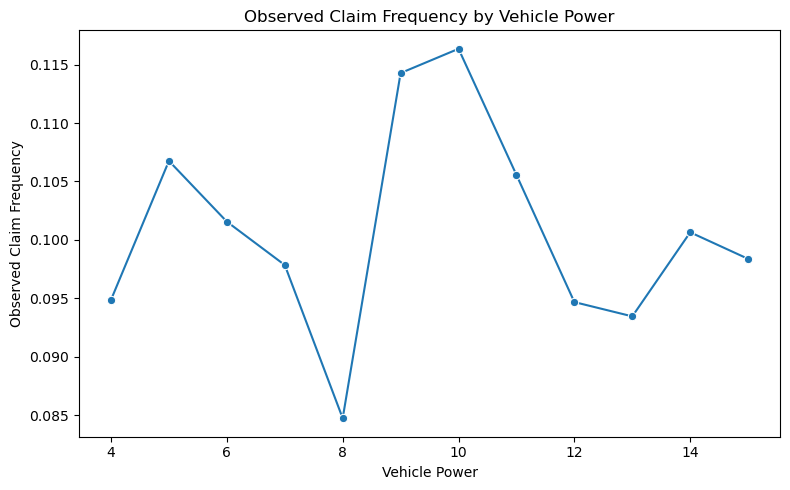

In [122]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=vehpower_freq,
    x="VehPower",
    y="observed_frequency",
    marker="o"
)

plt.title("Observed Claim Frequency by Vehicle Power")
plt.xlabel("Vehicle Power")
plt.ylabel("Observed Claim Frequency")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/claim_frequency_by_vehicle_power.png"
)

plt.show()

### Bonus-Malus Interpretation

Bonus-Malus is a historical risk indicator commonly used in insurance pricing systems.

Higher values generally correspond to:
- poorer historical claims experience
- higher expected future claim frequency

This variable often acts as a strong predictor because prior claims behavior may persist over time.

C:\Users\Asus\AppData\Local\Temp\ipykernel_23080\649030529.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bonusmalus_freq = df.groupby("BonusMalus").apply(


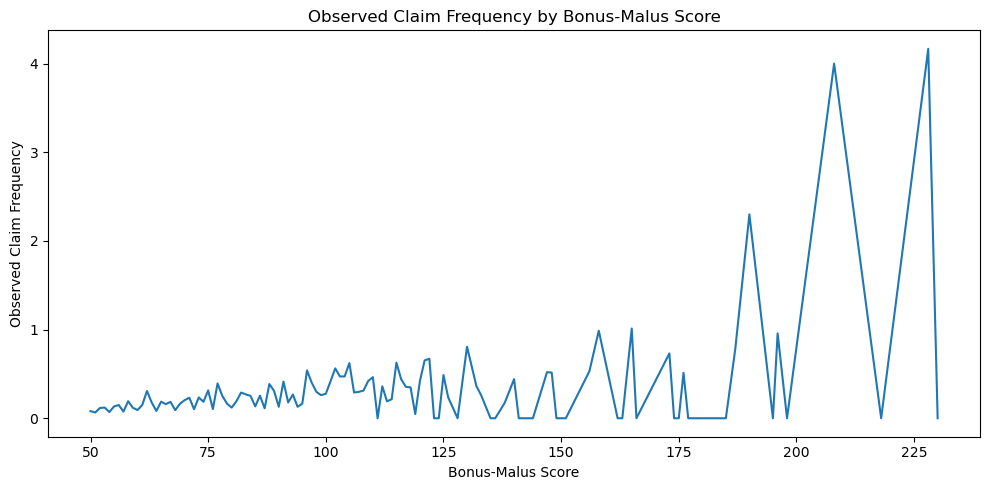

In [123]:
# Observed claim frequency by bonus-malus score
bonusmalus_freq = df.groupby("BonusMalus").apply(
    lambda x: x["ClaimNb"].sum() / x["Exposure"].sum()
).reset_index(name="observed_frequency")

bonusmalus_freq.head()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=bonusmalus_freq,
    x="BonusMalus",
    y="observed_frequency"
)

plt.title("Observed Claim Frequency by Bonus-Malus Score")
plt.xlabel("Bonus-Malus Score")
plt.ylabel("Observed Claim Frequency")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/claim_frequency_by_bonusmalus.png"
)

plt.show()

### Correlation Analysis

The correlation matrix provides an initial view of linear relationships between numerical variables.

In actuarial modeling, correlation analysis is useful for:

- identifying potentially informative predictors
- detecting multicollinearity
- understanding relationships between rating variables

However, low pairwise correlation does not necessarily imply that a variable lacks predictive value within a GLM framework.

In [124]:
# Correlation analysis for numerical variables
numeric_cols = [
    "DriverAge",
    "VehAge",
    "VehPower",
    "BonusMalus",
    "Density",
    "Exposure",
    "ClaimNb",
    "observed_frequency"
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,DriverAge,VehAge,VehPower,BonusMalus,Density,Exposure,ClaimNb,observed_frequency
DriverAge,1.000000,-0.060627,0.030134,-0.480157,-0.004716,0.171863,0.011386,-0.004057
VehAge,-0.060627,1.000000,-0.006553,0.081280,-0.092224,0.153751,-0.021896,-0.023833
VehPower,0.030134,-0.006553,1.000000,-0.075895,0.042901,-0.045259,-0.004259,-0.001779
BonusMalus,-0.480157,0.081280,-0.075895,1.000000,0.077717,-0.183018,0.050544,0.013806
Density,-0.004716,-0.092224,0.042901,0.077717,1.000000,-0.071085,0.010754,0.005744
Exposure,0.171863,0.153751,-0.045259,-0.183018,-0.071085,1.000000,0.068909,-0.051561
ClaimNb,0.011386,-0.021896,-0.004259,0.050544,0.010754,0.068909,1.000000,0.258469
observed_frequency,-0.004057,-0.023833,-0.001779,0.013806,0.005744,-0.051561,0.258469,1.000000


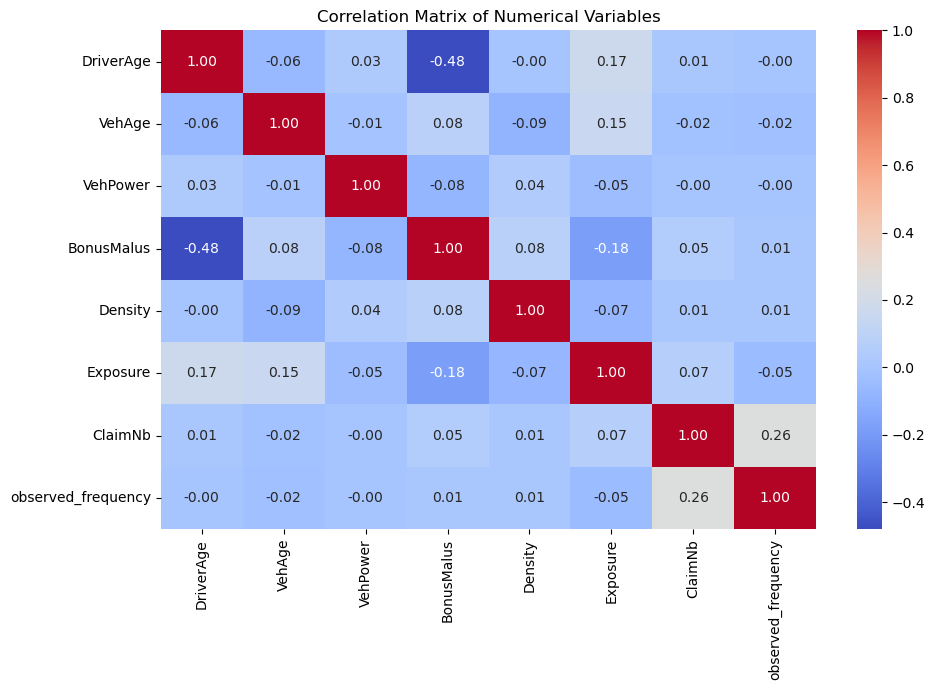

In [125]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/correlation_matrix.png"
)

plt.show()

## 5. Claim Frequency Modeling using Poisson GLM

This section builds a Poisson Generalized Linear Model (GLM) to estimate expected claim frequency.

In insurance pricing, claim counts are commonly modeled using Poisson regression because:

- claims are count outcomes
- claim counts are non-negative integers
- most policies generate zero claims
- claim frequency is naturally modeled as a rate

The model incorporates exposure as a log offset so that predicted values represent expected claim frequency rather than raw claim counts.

### Concept: Poisson Distribution



The Poisson distribution is commonly used to model the number of times an event occurs within a fixed exposure period.

Examples include:
- number of insurance claims
- number of hospital visits
- number of defaults

The Poisson GLM assumes:

- claim events occur independently
- expected claim count is related to rating variables
- variance is approximately proportional to the mean

Although real insurance data may exhibit overdispersion, the Poisson GLM remains a widely used baseline actuarial frequency model.

### Concept: Exposure Offset



Policies are active for different durations.

A policy insured for:
- 12 months
- 6 months
- 3 months

does not have equal opportunity to generate claims.

To account for this, the model includes:

log(Exposure)

as an offset term.

This allows the GLM to estimate claim frequency on a comparable exposure-adjusted basis.

### Rating Variables

The model includes:

- driver characteristics
- vehicle characteristics
- geographic variables
- prior risk indicators

Categorical variables are wrapped using `C()` so that the GLM treats them as rating classes rather than continuous numerical quantities.

In [126]:
# Define GLM formula for claim frequency modeling
formula = """
ClaimNb_capped ~ DriverAge
                 + VehAge
                 + VehPower
                 + BonusMalus
                 + Density
                 + C(Area)
                 + C(VehGas)
                 + C(Region)
"""

### Model Estimation

The GLM estimates the relationship between rating variables and expected claim count.

The log link function transforms the model into a multiplicative pricing structure, which aligns naturally with actuarial ratemaking frameworks.

In [127]:
# Fit Poisson GLM with exposure offset
frequency_model = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Poisson(),
    offset=np.log(df["Exposure"])
).fit()

### Model Output Interpretation



#### Concept: Log Link Function



The Poisson GLM uses a log link:

Expected Claims = exp(Xβ)

This ensures predicted claim counts remain positive.

The log link also creates a multiplicative interpretation:

- coefficient increases become multiplicative risk adjustments
- exponentiated coefficients behave like rating factors

#### The GLM summary includes:

- coefficients
- standard errors
- z-statistics
- p-values
- confidence intervals
- deviance statistics
- AIC



In [128]:
# Display model summary
print(frequency_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         ClaimNb_capped   No. Observations:               678013
Model:                            GLM   Df Residuals:                   677980
Model Family:                 Poisson   Df Model:                           32
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4308e+05
Date:                Sat, 23 May 2026   Deviance:                   2.1685e+05
Time:                        16:48:37   Pearson chi2:                 1.76e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01041
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -3

Important interpretation points:

- positive coefficients increase expected claim frequency
- negative coefficients decrease expected claim frequency
- smaller p-values suggest stronger statistical evidence for a variable effect

### Predicted Claim Frequency

The model now produces an estimated claim frequency for each policy.

This represents the model's estimate of expected claims per unit exposure after accounting for:
- driver characteristics
- vehicle characteristics
- geographic effects
- prior risk indicators

In [129]:
# Generate predicted claim counts
df["predicted_claims"] = frequency_model.predict(
    df,
    offset=np.log(df["Exposure"])
)

In [130]:
# Convert predicted claim counts into predicted frequency
df["predicted_frequency"] = (
    df["predicted_claims"] / df["Exposure"]
)

df[
    [
        "ClaimNb",
        "Exposure",
        "observed_frequency",
        "predicted_frequency"
    ]
].head()

,ClaimNb,Exposure,observed_frequency,predicted_frequency
0,1,0.10,10.000000,0.129193
1,1,0.77,1.298701,0.129193
2,1,0.75,1.333333,0.098786
3,1,0.09,11.111111,0.090523
4,1,0.84,1.190476,0.090523


### Rating Factors

Exponentiated GLM coefficients behave similarly to actuarial rating factors.

Examples:

- rating factor > 1
  → increases expected claim frequency

- rating factor < 1
  → decreases expected claim frequency

This interpretation is one reason GLMs remain highly popular in insurance pricing.

In [131]:
# Convert coefficients into actuarial-style rating factors
rating_factors = pd.DataFrame({
    "variable": frequency_model.params.index,
    "coefficient": frequency_model.params.values,
    "rating_factor": np.exp(frequency_model.params.values)
})

rating_factors.head(20)

,variable,coefficient,rating_factor
0,Intercept,-3.908627,0.020068
1,C(Area)[T.'B'],0.051430,1.052776
2,C(Area)[T.'C'],0.085067,1.088790
3,C(Area)[T.'D'],0.176709,1.193284
4,C(Area)[T.'E'],0.218479,1.244183
5,C(Area)[T.'F'],0.208901,1.232323
6,C(VehGas)[T.'Regular'],0.061794,1.063744
7,C(Region)[T.'R21'],0.143340,1.154122
8,C(Region)[T.'R22'],0.039772,1.040574
9,C(Region)[T.'R23'],-0.095531,0.908890


### Model Diagnostics

These statistics provide an initial view of model fit.

- AIC helps compare competing models
- Deviance measures goodness of fit
- Pearson Chi-Square may help identify overdispersion

Insurance claim data frequently exhibits overdispersion because:
- claims are heterogeneous
- many policies have zero claims
- some policies generate unusually high claim activity

More advanced models such as Negative Binomial or Tweedie GLMs may later be explored to address this issue.

In [132]:
# Basic model diagnostics
print("AIC:", frequency_model.aic)
print("Deviance:", frequency_model.deviance)
print("Pearson Chi2:", frequency_model.pearson_chi2)

AIC: 286233.12161617697
Deviance: 216850.68740513848
Pearson Chi2: 1758501.0804852569


## 6. Risk Segmentation and Pricing Interpretation

The predicted claim frequencies from the GLM can be used to segment policies into different risk groups.

Risk segmentation is a core actuarial pricing concept because insurers charge different premiums based on expected risk.

Policies with:
- higher expected claim frequency
- higher expected severity
- higher expected total cost

typically require higher premium levels.

This section evaluates whether the model meaningfully differentiates policies by estimated risk.

### Concept: Risk Segmentation



Risk segmentation groups policies into categories with similar expected risk profiles.

In insurance pricing, segmentation helps:
- improve premium adequacy
- reduce adverse selection
- identify high-risk portfolios
- support pricing fairness and interpretability

The GLM predictions are used here to construct risk bands based on predicted claim frequency.

### Quantile-Based Risk Bands

Policies are divided into deciles based on predicted claim frequency.

- Risk Band 1
  → lowest predicted risk

- Risk Band 10
  → highest predicted risk

This allows comparison between lower-risk and higher-risk segments of the portfolio.

In [133]:
# Create risk bands using predicted claim frequency
df["risk_band"] = pd.qcut(
    df["predicted_frequency"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

### Observed vs Predicted Frequency

A useful pricing model should produce increasing observed claim frequency across higher predicted risk bands.

If observed frequency rises consistently with predicted frequency, this suggests the model is successfully ranking policies by relative risk.

In [134]:
# Summarize portfolio statistics by risk band
risk_summary = df.groupby("risk_band").agg(
    policy_count=("ClaimNb", "count"),
    avg_predicted_frequency=("predicted_frequency", "mean"),
    total_claims=("ClaimNb", "sum"),
    total_exposure=("Exposure", "sum")
).reset_index()

# Calculate observed frequency by band
risk_summary["observed_frequency"] = (
    risk_summary["total_claims"] /
    risk_summary["total_exposure"]
)

risk_summary

,risk_band,policy_count,avg_predicted_frequency,total_claims,total_exposure,observed_frequency
0,1,67802,0.051693,2061,43615.878068,0.047253
1,2,67801,0.065203,2833,42731.244765,0.066298
2,3,67801,0.074759,3100,41577.226218,0.074560
3,4,67802,0.083565,3246,39655.957480,0.081854
4,5,67801,0.091942,3224,37423.526358,0.086149
5,6,67801,0.100353,3534,35128.231676,0.100603
6,7,67806,0.109783,3714,32909.859052,0.112854
7,8,67796,0.122215,3982,30770.961286,0.129408
8,9,67801,0.145608,4438,28339.522065,0.156601
9,10,67802,0.232497,5970,26347.038496,0.226591


### Interpretation of Risk Bands

If the model is effective, the following pattern should generally appear:

- lower risk bands
  → lower observed claim frequency

- higher risk bands
  → higher observed claim frequency

Perfect alignment is not expected because insurance claims contain randomness and unobserved behavioral effects.

However, meaningful separation between risk groups indicates that the GLM captures useful predictive structure within the portfolio.

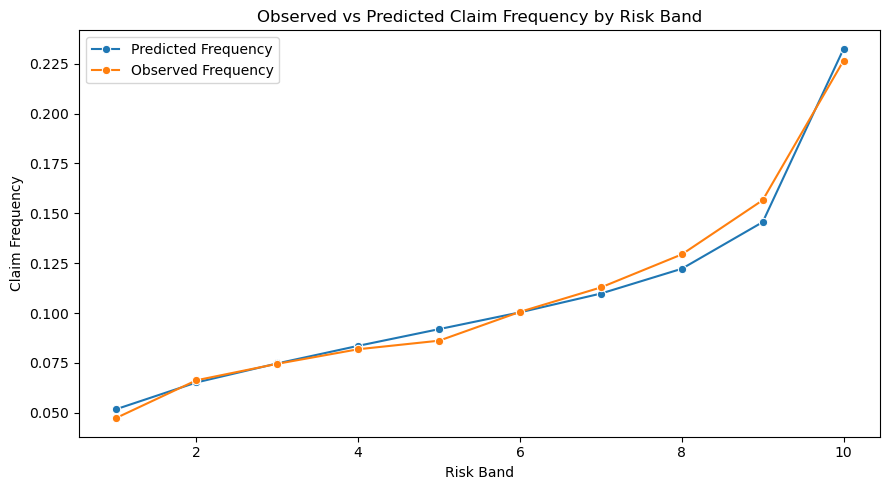

In [135]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=risk_summary,
    x="risk_band",
    y="avg_predicted_frequency",
    marker="o",
    label="Predicted Frequency"
)

sns.lineplot(
    data=risk_summary,
    x="risk_band",
    y="observed_frequency",
    marker="o",
    label="Observed Frequency"
)

plt.title("Observed vs Predicted Claim Frequency by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Claim Frequency")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/observed_vs_predicted_risk_bands.png"
)

plt.show()

### Scenario-Based Premium Illustration

Because the current dataset does not include claim severity amounts, a simplified premium illustration is constructed using an assumed average claim cost.

This is not a final actuarial premium model.

Instead, it demonstrates how predicted frequency estimates may contribute to pricing calculations within a broader frequency-severity framework.

In [136]:
# Assumed average claim cost for pricing illustration
assumed_average_claim_cost = 3000

# Scenario-based premium estimate
df["scenario_premium"] = (
    df["predicted_frequency"] *
    assumed_average_claim_cost
)

df[
    [
        "predicted_frequency",
        "scenario_premium"
    ]
].describe()

,predicted_frequency,scenario_premium
count,678013.000000,678013.000000
mean,0.107762,323.285139
std,0.057548,172.643830
min,0.018344,55.030759
25%,0.074786,224.359032
50%,0.096059,288.177399
75%,0.121858,365.573520
max,8.078085,24234.255508


In [137]:
# Average scenario premium by risk band
premium_summary = df.groupby("risk_band").agg(
    avg_scenario_premium=("scenario_premium", "mean")
).reset_index()

premium_summary

,risk_band,avg_scenario_premium
0,1,155.077769
1,2,195.609450
2,3,224.275771
3,4,250.693731
4,5,275.826030
5,6,301.058160
6,7,329.349275
7,8,366.646255
8,9,436.824018
9,10,697.491712


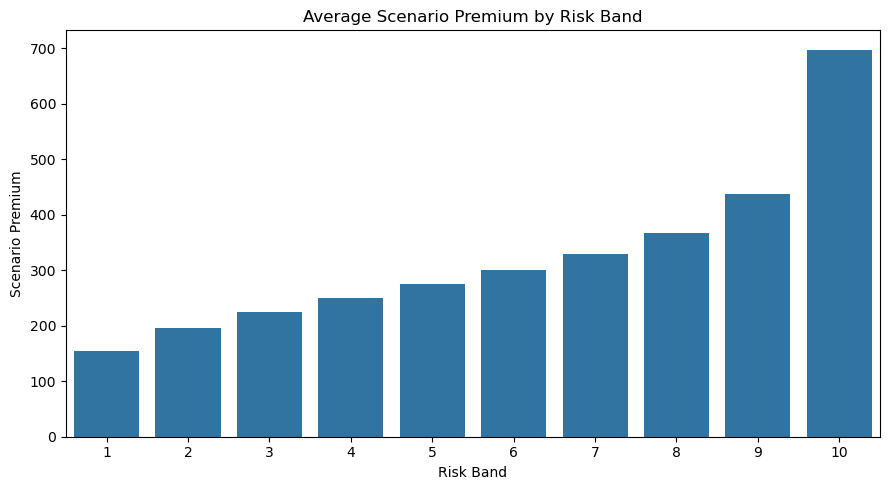

In [138]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=premium_summary,
    x="risk_band",
    y="avg_scenario_premium"
)

plt.title("Average Scenario Premium by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Scenario Premium")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/scenario_premium_by_risk_band.png"
)

plt.show()

### Pricing Interpretation

The scenario premium illustration shows how increasing predicted claim frequency translates into higher expected insurance cost.

In practice, full actuarial pricing models would additionally incorporate:

- claim severity modeling
- expenses
- profit margins
- reinsurance costs
- regulatory considerations
- credibility adjustments

This notebook focuses primarily on the claim frequency component of the pricing framework.

In [139]:
# Save risk segmentation outputs
risk_summary.to_csv(
    "../outputs/tables/risk_band_summary.csv",
    index=False
)

premium_summary.to_csv(
    "../outputs/tables/premium_summary.csv",
    index=False
)

df.to_csv(
    "../data/processed/frequency_model_predictions.csv",
    index=False
)

## 7. Model Evaluation and Limitations

This section evaluates the strengths and limitations of the Poisson GLM frequency model.

Although the model captures meaningful portfolio structure, insurance claim data is inherently noisy and influenced by many unobserved factors.

The goal is therefore not perfect prediction, but useful and interpretable risk estimation.

### Concept: Model Evaluation in Insurance



Insurance models are evaluated using both:

- statistical fit
- business usefulness

A model may not perfectly predict every claim outcome, but it can still provide strong pricing value if it consistently separates lower-risk and higher-risk policies.

### Portfolio-Level Calibration

A useful pricing model should produce portfolio-level predictions that are reasonably close to observed portfolio experience.

Large discrepancies may indicate:
- poor calibration
- missing predictors
- incorrect assumptions
- instability within the model structure

In [140]:
# Compare observed and predicted portfolio-level frequency
portfolio_observed_frequency = (
    df["ClaimNb"].sum() /
    df["Exposure"].sum()
)

portfolio_predicted_frequency = (
    df["predicted_claims"].sum() /
    df["Exposure"].sum()
)

print("Observed Portfolio Frequency:")
print(portfolio_observed_frequency)

print("\nPredicted Portfolio Frequency:")
print(portfolio_predicted_frequency)

Observed Portfolio Frequency:
0.10070308464041304

Predicted Portfolio Frequency:
0.10057477202912714


### Residuals

Residuals measure the difference between:

- observed claims
- predicted claims

Large residuals may indicate:
- unusual policies
- unmodeled risk factors
- structural limitations in the GLM

In [141]:
# Residual calculation
df["raw_residual"] = (
    df["ClaimNb"] -
    df["predicted_claims"]
)

df[
    [
        "ClaimNb",
        "predicted_claims",
        "raw_residual"
    ]
].head()

,ClaimNb,predicted_claims,raw_residual
0,1,0.012919,0.987081
1,1,0.099479,0.900521
2,1,0.074089,0.925911
3,1,0.008147,0.991853
4,1,0.076039,0.923961


### Residual Distribution

The residual distribution helps evaluate whether prediction errors appear systematically biased.

Insurance frequency models often exhibit:
- skewness
- heavy tails
- excess zeros

because claim processes are highly heterogeneous.

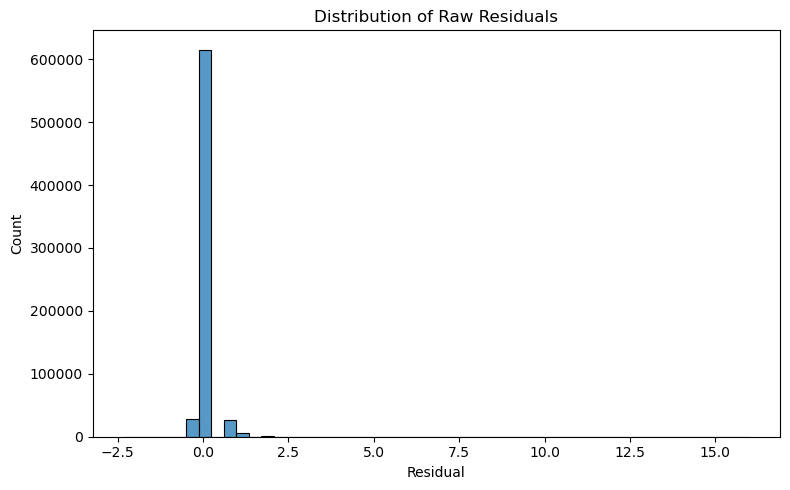

In [142]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["raw_residual"],
    bins=50
)

plt.title("Distribution of Raw Residuals")
plt.xlabel("Residual")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/raw_residual_distribution.png"
)

plt.show()

### Segment-Level Validation

Comparing observed and predicted frequency across portfolio segments helps determine whether the model captures broad risk trends.

A strong pricing model should generally preserve the relative ordering of risk groups, even if individual claim outcomes remain unpredictable.

In [143]:
# Compare observed vs predicted claims by age band
age_model_check = df.groupby("age_band").agg(
    observed_claims=("ClaimNb", "sum"),
    predicted_claims=("predicted_claims", "sum"),
    exposure=("Exposure", "sum")
).reset_index()

age_model_check["observed_frequency"] = (
    age_model_check["observed_claims"] /
    age_model_check["exposure"]
)

age_model_check["predicted_frequency"] = (
    age_model_check["predicted_claims"] /
    age_model_check["exposure"]
)

age_model_check

C:\Users\Asus\AppData\Local\Temp\ipykernel_23080\41285099.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_model_check = df.groupby("age_band").agg(


,age_band,observed_claims,predicted_claims,exposure,observed_frequency,predicted_frequency
0,18-25,2841,2609.948648,16227.903263,0.175069,0.160831
1,26-35,6662,7687.207992,69266.778075,0.096179,0.110980
2,36-45,8397,7996.940278,87702.336287,0.095744,0.091183
3,46-55,9256,8171.764907,89268.776408,0.103687,0.091541
4,56-65,4748,5060.296372,51775.553261,0.091704,0.097735
5,65+,4198,4529.841803,44258.098168,0.094853,0.102351


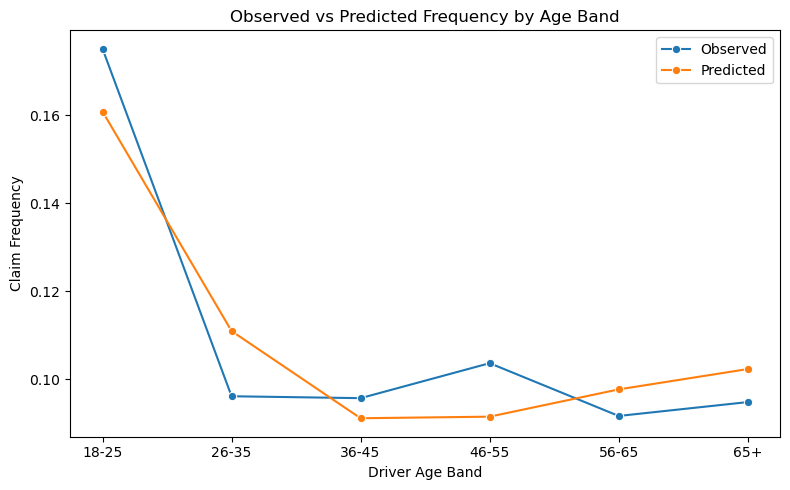

In [144]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=age_model_check,
    x="age_band",
    y="observed_frequency",
    marker="o",
    label="Observed"
)

sns.lineplot(
    data=age_model_check,
    x="age_band",
    y="predicted_frequency",
    marker="o",
    label="Predicted"
)

plt.title("Observed vs Predicted Frequency by Age Band")
plt.xlabel("Driver Age Band")
plt.ylabel("Claim Frequency")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/age_band_model_validation.png"
)

plt.show()

### Model Limitations

Several important limitations apply to this project:

- the current dataset does not include claim severity amounts
- severity modeling is therefore not yet implemented
- the Poisson GLM may underestimate variance due to overdispersion
- unobserved behavioral variables may influence claims
- no train/test validation split is currently included
- the project focuses primarily on interpretability rather than maximizing predictive accuracy

### Potential Improvements

Several extensions could improve the pricing framework:

- Gamma GLM severity modeling
- Pure premium estimation
- Negative Binomial GLMs
- Tweedie GLMs
- XGBoost comparison models
- train/test validation
- hyperparameter tuning
- advanced residual diagnostics
- temporal validation
- dashboard visualization

## 8. Conclusion

This project explored actuarial claim frequency modeling using a motor insurance portfolio dataset.

A Poisson Generalized Linear Model (GLM) was developed to estimate expected claim frequency using:

- driver characteristics
- vehicle characteristics
- geographic variables
- prior risk indicators
- exposure-adjusted claim data

The analysis demonstrated how actuarial pricing models can:

- estimate expected insurance risk
- segment policies into risk groups
- generate interpretable rating factors
- support pricing-oriented decision frameworks

The project also highlighted important actuarial modeling considerations such as:

- exposure adjustment
- overdispersion
- portfolio heterogeneity
- interpretability
- risk segmentation

Although the current implementation focuses primarily on claim frequency, the framework establishes a strong foundation for future extensions including:

- severity modeling
- pure premium estimation
- Tweedie GLMs
- machine learning comparison models

Overall, the project demonstrates a practical actuarial workflow combining statistical modeling, exploratory analysis, and insurance pricing interpretation using Python and GLMs.

In [145]:
print("Motor insurance frequency modeling project completed.")

Motor insurance frequency modeling project completed.
